---
tags: [algorithm, optimization, variational]
---

# 組合せ最適化のための量子強化型マルコフ連鎖モンテカルロ法

量子コンピュータは、従来の古典コンピューティングとは異なるアプローチから、組合せ最適化問題を効率的に解く可能性を持ちます。
しかし、最先端の古典ソルバーでも困難な規模の量子最適化計算は、依然として難しいままです。
最近、複雑な確率分布の近似において、量子強化型マルコフ連鎖モンテカルロ法 (QeMCMC) が有望な結果を示しました。
このことを受けて、[Marshall et al. (2026)](https://arxiv.org/abs/2602.06171) では、デバイスからのサンプリングと QeMCMC 手法に、ウォームスタートとパラレルテンパリングとを組合せた手法を考案しました。
このページでは、Qamomile を用いた [Marshall et al. (2026)](https://arxiv.org/abs/2602.06171) の実装例を示しています。

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from qiskit_aer import AerSimulator

import qamomile.circuit as qmc
from qamomile.circuit.algorithm.qaoa import ising_cost
from qamomile.qiskit import QiskitTranspiler

## 背景

### 組合せ最適化と量子コンピューティング

組合せ最適化は、量子コンピューティングの重要な応用分野の一つです。
古典アルゴリズムに対し、大幅な高速化をもたらす可能性のある量子最適化アルゴリズムが、広く研究されてきました。
その代表例に、量子近似最適化アルゴリズム (QAOA) があります ([Farhi et al. (2014)](https://arxiv.org/abs/1411.4028) など)。
しかし、現行の量子ハードウェアにはノイズが存在するため、量子ビット数や depth が制限されます。
QAOA を改良する方法として、初期状態を古典最適化から求める warm-starting 技法などが提案されてきました。
しかし warm-starting QAOA は、初期状態として準備された解に強く依存することが知られています。
初期に与えられた解の周辺に探索が偏るために、良い初期解が与えられればその周囲を詳しく探索できる一方で、エネルギー障壁を超えた先にあるより良い解へ移動しにくくなる可能性を持ちます。

### 先行研究: QeMCMC

[Marshall et al. (2026)](https://arxiv.org/abs/2602.06171) を理解する上で重要な先行研究として、QeMCMC を提案した [Layden et al. (2023)](https://www.nature.com/articles/s41586-023-06095-4) が挙げられます。
QeMCMC では、MCMC の提案部分に量子コンピュータを用います。
量子ダイナミクスを活用し、エネルギーは近いのに状態としては遠い状態を提案できないかと考えたのです。  
現在の MCMC 状態を $\mathbf{s}$ とし、それに対応する量子コンピュータ上での計算基底状態を $\vert \mathbf{s} \rangle$ のように準備します。
その状態に $U = e^{-iHt}$ を作用させ

$$
\vert \mathbf{s} \rangle \ \xrightarrow{U} \ U \vert \mathbf{s} \rangle 
= \sum_{\mathbf{s}'} c_{\mathbf{s}'} \vert \mathbf{s}' \rangle \tag{1}
$$

とします。
最後に計算基底で測定することで、$\mathbf{s}'$ が得られ、その確率は

$$
Q_\mathrm{Q} (\mathbf{s}' \vert \mathbf{s}) 
= \vert \langle \mathbf{s}' \vert U \vert \mathbf{s} \rangle \vert^2 \tag{2}
$$

です。
これを MCMC の提案として用いるというものです。
量子コンピュータを用いて提案分布を生成し、古典コンピュータがそれを受理・棄却を判断します。
ここで $U$ に、詳細釣り合いに対応する $\vert \langle \mathbf{s}' \vert U \vert \mathbf{s} \rangle \vert = \vert \langle \mathbf{s} \vert U \vert \mathbf{s}' \rangle \vert$ という条件を課すことにしましょう。
すると、提案分布の受理確率が

$$
A(\mathbf{s}' \vert \mathbf{s}) 
= \min \left[ 1, e^{-\Delta E / T} \right] \tag{3}
$$

のようになります。
古典的に困難な量子分布からのサンプリングを実現しつつ、量子確率 $Q_\mathrm{Q}$ 自体は計算しなくてもよいことがわかります。  
先ほどの $U$ として、[Layden et al. (2023)](https://www.nature.com/articles/s41586-023-06095-4) では

$$
H 
= (1 - \kappa) \alpha H_\mathrm{prob} + \kappa H_\mathrm{mix} \tag{4}
$$

のような形を採用しました。
ここで

$$
H_\mathrm{prob} 
= - \sum_{i>j} J_{ij} Z_i Z_j - \sum_i h_i Z_i 
= \sum_\mathbf{s} E(\mathbf{s}) \vert \mathbf{s} \rangle \langle \mathbf{s} \vert \tag{5}
$$

であり、これは古典イジング模型のエネルギーランドスケープを量子ハミルトニアンに埋め込んだものです。
ミキサーハミルトニアンとしては、単純に

$$
H_\mathrm{mix} 
= \sum_i X_i \tag{6}
$$

を用いており、量子遷移を促します。
ここで $\alpha = \| H_\mathrm{mix} \|_F / \| H_\mathrm{prob} \|_F$ は、規格化定数です。  
QAOA とは異なり、QeMCMC においては $\kappa, t$ は最適化のための変分パラメータではありません。
各 MCMC の反復ごとに $\kappa = \mathrm{Uniform} [0.25, 0.6], t = \mathrm{Uniform} [2, 20]$ のように選びます。
QeMCMC の詳細や実装については、ぜひ[こちらの記事](https://jij-inc-qamomile.readthedocs-hosted.com/latest/ja/algorithm/qe-mcmc/)もご覧ください。

## 提案手法

### QAOA との対応

[Layden et al. (2023)](https://www.nature.com/articles/s41586-023-06095-4) の「量子回路を提案分布生成器として用いる」という考え方を継承し、これを組合せ最適化の基底状態を効率よく探索する方法を提案したのが [Marshall et al. (2026)](https://arxiv.org/abs/2602.06171) です。
先ほどの $H_\mathrm{prob}$ の部分を、組合せ最適化問題をイジングハミルトニアンで表現したものに置き換えます。

$$
H 
= (1 - \kappa) \alpha H_\mathrm{cost} + \kappa H_\mathrm{mix} \tag{7}
$$

すると

$$
U 
= e^{-it\{(1-\kappa) \alpha H_\mathrm{cost} + \kappa H_\mathrm{mix}\}} 
\underbrace{\approx}_{\mathrm{Trotter \ decomposition}} e^{-it \kappa H_\mathrm{mix}} e^{-it(1-\kappa) \alpha H_\mathrm{cost}} \tag{8}
$$

となります。
これを 2 つの同じトロッターステップにすると

$$
e^{-itH} 
\approx \left(e^{-i\beta H_\mathrm{mix}} e^{-i\gamma H_\mathrm{cost}} \right)^2, \quad 
\left( \gamma = \frac{t}{2} (1 - \kappa) \alpha, \ \beta = \frac{t}{2} \kappa \right) \tag{9}
$$

のように整理できます。
これは p = 2 の QAOA に似た量子回路に他なりません。

### ウォームスタート

これまで説明してきた QeMCMC と異なり、[Marshall et al. (2026)](https://arxiv.org/abs/2602.06171) では、現在の受理された状態 $\vert \mathbf{s}_k \rangle$ をウォームスタートにします。
正則化パラメータ $0 < \epsilon < 1/2$ を導入し、次のようにソフトニングを行います。

$$
\tilde{s}_i 
= \left\{ \begin{array}{ll}
\epsilon & s_i = 0 \\
1 - \epsilon & s_i = 1  
\end{array} \right. \tag{10}
$$

これを用い、角度を $\theta_i = 2 \mathrm{arcsin} \sqrt{\tilde{s}_i}$ のようにすることで、この状態に対応した量子状態

$$
\vert \psi_\mathrm{WS} (s_k) \rangle 
= \bigotimes_i R_y (\theta_i) \vert 0 \rangle \tag{11}
$$

を作成します。
WS-QAOA のときと同様、ミキサーもこれに合わせて変更を行います。
具体的には

$$
H_{\mathrm{mix}, i}^{(\mathrm{WS})} 
= - \sin \theta_i X_i - \cos \theta_i Z_i \tag{12}
$$

のようにすることで、$\vert \psi_\mathrm{WS} \rangle$ がミキサーの基底状態になります。
従って、[Marshall et al. (2026)](https://arxiv.org/abs/2602.06171) では各反復で現在の状態 $s_k$ が変更するたびに $\theta_i (s_k)$ が変化し、それに合わせて初期状態とミキサーの変更も行います。
つまりこの提案は、WS-QAOA をマルコフ連鎖の動的な生成器として扱うと言えるでしょう。

### パラレルテンパリング (レプリカ交換法)

通常の MCMC では、式 (2) の温度 $T$ を固定して計算を行います。
しかしこの場合、局所解に囚われる可能性があります。
そこで複数の異なる温度 $T_a$ の MCMC の計算を、並列に行うことにしましょう。
この異なる温度での計算を、レプリカと呼びます。
高温極限では、$e^{-\Delta E / T} \rightarrow 1$ となるため、MCMC はエネルギー差に関係なく幅広く探索を行います。
反対に低温極限では、MCMC は低エネルギーの解の近辺を細かく探索するようになります。
二つの温度のレプリカ $T_r < T_{r'}$ において、まず $T_{r'}$ のレプリカが幅広く探索します。
そこで良いエネルギーの谷を見つけたら、温度を $T_r$ に交換し、細かく低エネルギーの解の探索を行う、というのがパラレルテンパリングです。
レプリカ $r, r'$ の交換確率は、次のように与えられます。

$$
A_\mathrm{exchange} (\mathbf{s}_r, \mathbf{s}_{r'})
= \min \left[ 1, \exp \left\{ \left( \frac{1}{T_r} - \frac{1}{T_{r'}} \right) (E(\mathbf{s}_{r}) - E(\mathbf{s}_{r'})) \right\} \right] \tag{13}
$$

### アルゴリズムの流れ

ここまでの話から、[Marshall et al. (2026)](https://arxiv.org/abs/2602.06171) で提案されたアルゴリズムの流れをまとめます。

1. QAOA の $\beta, \gamma$、ウォームスタートのための正則化パラメータ $\epsilon$、各レプリカの温度 $T_r \ (r = 1, 2, \dots, R)$ を決める。
2. 複数の温度のレプリカを初期化する。
3. 各レプリカの現在の解 $\mathbf{s}_k^{(r)}$ から、$\vert \psi_\mathrm{WS}(\mathbf{s}_k^{(r)}) \rangle$ を作り、対応するウォームスタートミキサーを設定する。
4. $p = 2$ の QAOA に似た量子回路を実行し、多数の候補を生成する。
5. 多数の測定の中から低エネルギーの候補だけを残し、その中から次の提案分布を選ぶ。
6. メトロポリス・ヘイスティングアルゴリズムにより、提案分布を受理するかを決定します。
7. 一定のステップ間隔で、隣接する温度のレプリカ間の状態を交換する。
8. 3-7 を繰り返す

Depth の深い量子回路を一度だけ実行するのでなく、浅い量子回路を反復することで、最適解の発見を目指す手法になっていることがわかります。
また、標準的なウォームスタート QAOA とは異なり、初期に準備するウォームスタート状態も固定されていません。
QeMCMC による解の探索に任せるだけでなく、反復ごとにウォームスタート状態を作り直すことで、良い解へと近づいていくようなイメージです。

## Qamomile を用いた実装

ここまで説明してきた、QeMCMC を組合せ最適化計算に応用した手法を、Qamomile で実装しましょう。

### インスタンスの生成

ここではグリッド状に配置された頂点をもつグラフを生成し、その最大独立集合問題 (MIS) を解くことにします。

In [2]:
# 18-node graph: 3 x 6 grid
n_rows = 3
n_cols = 6
n = n_rows * n_cols

edges = []
for row in range(n_rows):
    for col in range(n_cols):
        node = row * n_cols + col
        if col + 1 < n_cols:
            edges.append((node, node + 1))
        if row + 1 < n_rows:
            edges.append((node, node + n_cols))

生成されたグラフを、可視化してみましょう。

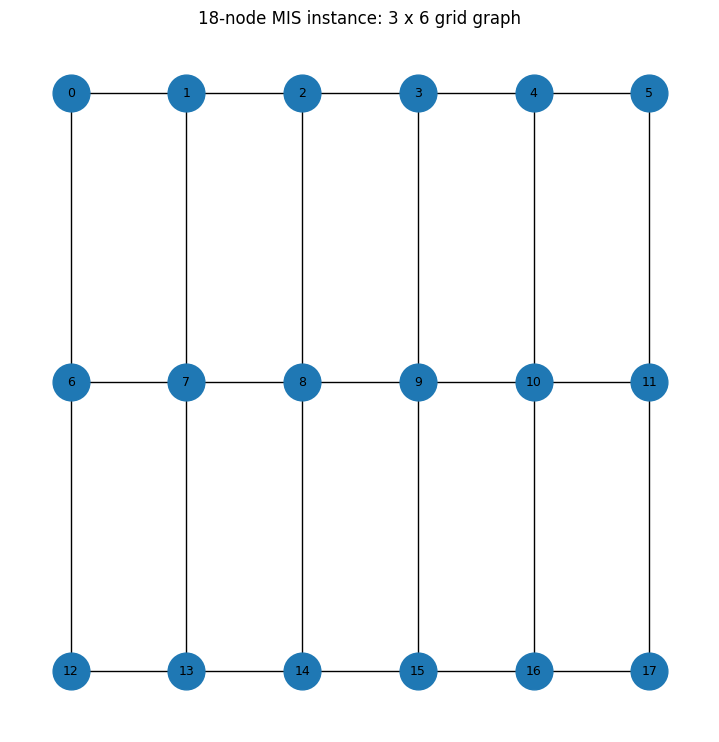

In [3]:
graph = nx.Graph()
graph.add_nodes_from(range(n))
graph.add_edges_from(edges)

positions = {
    row * n_cols + col: (col, -row)
    for row in range(n_rows)
    for col in range(n_cols)
}

plt.figure(figsize=(7, 7))
nx.draw(
    graph,
    pos=positions,
    with_labels=True,
    node_size=700,
    font_size=9,
)
plt.title("18-node MIS instance: 3 x 6 grid graph")
plt.show()

### 各種パラメータの設定

以降のスクリプトで用いるパラメータを初期化します。

* `penalty`: MIS を QUBO にしたときのペナルティ項の係数
* `epsilon`: ウォームスタートに用いる正則化パラメータ
* `gamma, beta`: 式 (9) で定義される QAOA に似た回路のパラメータ
* `shots`: 量子回路の測定回数
* `top_k`: 低エネルギー状態のうち候補として抽出する個数
* `num_replicas`: レプリカ交換法に用いるレプリカの個数
* `temperatures`: レプリカの温度
* `swap_interval`: レプリカ交換を行うステップ数
* `max_iterations`: 最大反復回数

In [4]:
# Set seed of random numbers
rng = np.random.default_rng()

# MIS penalty. lambda = 2 is sufficient for this educational QUBO.
penalty = 2.0

# Warm-start / QAOA-like proposal parameters
# Paper: p=2 with gamma_1 = gamma_2 and beta_1 = beta_2.
epsilon = 0.25
gamma = 0.70
beta = 0.40

# Multi-shot low-energy selection.
shots = 128
top_k = 10

# Parallel tempering
num_replicas = 5
temperatures = np.geomspace(0.05, 2.0, num_replicas)
swap_interval = 1
max_iterations = 20

print("n             =", n)
print("number edges  =", len(edges))
print("temperatures  =", temperatures)

n             = 18
number edges  = 27
temperatures  = [0.05       0.12574334 0.31622777 0.79527073 2.        ]


### イジングハミルトニアンの生成

MIS のイジングハミルトニアンを生成しましょう。
そのために、まずは MIS の QUBO を考えます。

$$
H_\mathrm{QUBO} 
= - \sum_{v_i \in V} x_i + \lambda \sum_{(v_i, v_j) \in E} x_i x_j \tag{14}
$$

これをイジングハミルトニアンに変換するには、スピン変数とバイナリ変数の対応関係 $x_i = \frac{1 - Z_i}{2}$ を用います。
すると

$$
H_\mathrm{Ising} 
= - \frac{n}{2} + \frac{1}{2} \sum_{v_i \in V} Z_i + \sum_{(v_i, v_j) \in E} \left( \frac{\lambda}{4} - \frac{\lambda}{4} Z_i - \frac{\lambda}{4} Z_j + \frac{\lambda}{4} Z_i Z_j \right) 
= - \frac{n}{2} + \frac{\lambda \vert E \vert}{4} + \sum_i \left( \frac{1}{2} - \frac{\lambda d_i}{4} \right) Z_i + \frac{\lambda}{4} \sum_{(v_i, v_j) \in E} Z_i Z_j \tag{15}
$$

を得ます。
途中の式変形では、各頂点に接続する辺の数 (次数) $d_i$ を用いることで、線形項と 2 次の項に分離しています。

In [5]:
# Degree of each vertex
degree = np.zeros(n, dtype=int)
for i, j in edges:
    degree[i] += 1
    degree[j] += 1

# H_cost = constant + sum_i linear[i] Z_i + sum_(i,j) quad[(i,j)] Z_i Z_j
linear = {
    i: float(0.5 - penalty * degree[i] / 4.0)
    for i in range(n)
}
quad = {
    (i, j): float(penalty / 4.0)
    for i, j in edges
}
constant = float(-n / 2.0 + penalty * len(edges) / 4.0)

print("constant =", constant)
print("linear   =", linear)
print("quad      =", quad)

constant = 4.5
linear   = {0: -0.5, 1: -1.0, 2: -1.0, 3: -1.0, 4: -1.0, 5: -0.5, 6: -1.0, 7: -1.5, 8: -1.5, 9: -1.5, 10: -1.5, 11: -1.0, 12: -0.5, 13: -1.0, 14: -1.0, 15: -1.0, 16: -1.0, 17: -0.5}
quad      = {(0, 1): 0.5, (0, 6): 0.5, (1, 2): 0.5, (1, 7): 0.5, (2, 3): 0.5, (2, 8): 0.5, (3, 4): 0.5, (3, 9): 0.5, (4, 5): 0.5, (4, 10): 0.5, (5, 11): 0.5, (6, 7): 0.5, (6, 12): 0.5, (7, 8): 0.5, (7, 13): 0.5, (8, 9): 0.5, (8, 14): 0.5, (9, 10): 0.5, (9, 15): 0.5, (10, 11): 0.5, (10, 16): 0.5, (11, 17): 0.5, (12, 13): 0.5, (13, 14): 0.5, (14, 15): 0.5, (15, 16): 0.5, (16, 17): 0.5}


### 最適解の計算

グリッド状に頂点が配置されている場合、MIS の最適解はチェッカーボード状に交互に頂点を選択した状態となります。
この後に実装する Qamomile による計算との比較のために、この事実を利用して最適なエネルギーを計算しましょう。

In [6]:
# One exact optimum for a 3 x 6 grid: checkerboard selection.
exact_state = np.zeros(n, dtype=int)
for row in range(n_rows):
    for col in range(n_cols):
        if (row + col) % 2 == 0:
            exact_state[row * n_cols + col] = 1

exact_energy = float(
    -exact_state.sum()
    + penalty * sum(exact_state[i] * exact_state[j] for i, j in edges)
)

print("QUBO/Ising random checks passed")
print("known optimum energy =", exact_energy)
print("MIS size             =", int(exact_state.sum()))
print("one optimum          =", np.flatnonzero(exact_state).tolist())

QUBO/Ising random checks passed
known optimum energy = -9.0
MIS size             = 9
one optimum          = [0, 2, 4, 7, 9, 11, 12, 14, 16]


### 量子カーネルの実装

現在の MCMC 状態から作られた $\theta_i$ を用い、ウォームスタート初期状態を準備します。
その後、Qamomile の `ising_cost` による $e^{-i \gamma H_\mathrm{Ising}}$ の実装と、ウォームスタート初期状態に合わせたミキサーの導入を行っています。

In [7]:
@qmc.qkernel
def marshall_warm_qaoa_sampling(
    n: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    thetas: qmc.Vector[qmc.Float],
    gamma: qmc.Float,
    beta: qmc.Float,
) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(n, name="q")

    # Warm-start initial state
    for i in qmc.range(n):
        q[i] = qmc.ry(q[i], thetas[i])

    # p = 2, gamma_1 = gamma_2 = gamma, beta_1 = beta_2 = beta
    q = ising_cost(quad, linear, q, gamma)
    for i in qmc.range(n):
        q[i] = qmc.ry(q[i], -thetas[i])
        q[i] = qmc.rz(q[i], -2.0 * beta)
        q[i] = qmc.ry(q[i], thetas[i])

    q = ising_cost(quad, linear, q, gamma)
    for i in qmc.range(n):
        q[i] = qmc.ry(q[i], -thetas[i])
        q[i] = qmc.rz(q[i], -2.0 * beta)
        q[i] = qmc.ry(q[i], thetas[i])

    return qmc.measure(q)

### 量子回路のトランスパイル

先ほど定義した量子カーネルを、Qiskit バックエンドで実行するためにトランスパイルしましょう。
ただし、量子ビット数 `n` と イジングハミルトニアンの情報 `linear`, `quad` は固定し、`thetas`, `gamma`, `beta` は柔軟に変更できるパラメータとして使えるようにします。

In [8]:
transpiler = QiskitTranspiler()

executable = transpiler.transpile(
    marshall_warm_qaoa_sampling,
    bindings={
        "n": n,
        "quad": quad,
        "linear": linear,
    },
    parameters=["thetas", "gamma", "beta"],
)

backend = AerSimulator(method="matrix_product_state")
executor = transpiler.executor(backend=backend)

print("transpilation complete")
print("Aer method = matrix_product_state")

transpilation complete
Aer method = matrix_product_state


### 各レプリカの初期状態の準備

レプリカ交換のために、`num_replicas` 個のランダムな初期ビット列を生成します。
またここで生成された初期状態のエネルギーを計算し、この時点でどのレプリカが一番低エネルギーかを記録します。

In [9]:
replica_states = [rng.integers(0, 2, size=n) for _ in range(num_replicas)]
replica_energies = np.array([
    -state.sum() + penalty * sum(state[i] * state[j] for i, j in edges)
    for state in replica_states
], dtype=float)

best_replica = int(np.argmin(replica_energies))
best_state = replica_states[best_replica].copy()
best_energy = float(replica_energies[best_replica])

# Store the best-so-far curve and every temperature slot after each full iteration.
history_best = [best_energy]
history_replicas = [replica_energies.copy()]

print("initial energies =", replica_energies.tolist())
print("initial best     =", best_energy)

initial energies = [-1.0, -3.0, 10.0, -1.0, 13.0]
initial best     = -3.0


### メインループ

ここまでで準備したものを用い、アルゴリズムのメインループを組み立てましょう。
各レプリカでウォームスタート QAOA を実施します。
各レプリカの測定を行い、提案分布を生成します。
測定された中から、低エネルギーのものを `top_k` 個抽出し、提案分布を選定します。
レプリカごとの温度を用いたメトロポリス・ヘイスティング法により、その提案分布の受理・棄却を判断し、受理された分布を次のウォームスタートに用います。
全てのレプリカの更新後には、隣接する温度間でレプリカ交換を行います。

In [10]:
for iteration in range(1, max_iterations + 1):
    # ----- Local QeMCMC-inspired update for every replica -----
    for r in range(num_replicas):
        state = replica_states[r]
        current_energy = float(replica_energies[r])
        temperature = float(temperatures[r])

        # Dynamic warm start from the currently accepted state.
        soft = np.where(state == 0, epsilon, 1.0 - epsilon)
        thetas = (2.0 * np.arcsin(np.sqrt(soft))).tolist()

        sample_result = executable.sample(
            executor,
            shots=shots,
            bindings={
                "thetas": thetas,
                "gamma": gamma,
                "beta": beta,
            },
        ).result()

        # Preserve multiplicity of measured bitstrings.
        shot_states = []
        for outcome, count in sample_result.results:
            bits = np.asarray(outcome, dtype=int)
            for _ in range(count):
                shot_states.append(bits.copy())

        shot_energies = np.array([
            -bits.sum() + penalty * sum(bits[i] * bits[j] for i, j in edges)
            for bits in shot_states
        ], dtype=float)

        # Keep the low-energy tail. Include all ties at the top_k cutoff.
        sorted_energy = np.sort(shot_energies)
        cutoff_energy = sorted_energy[min(top_k - 1, len(sorted_energy) - 1)]
        pool_indices = np.flatnonzero(shot_energies <= cutoff_energy)
        proposal_index = int(rng.choice(pool_indices))
        proposal_state = shot_states[proposal_index].copy()
        proposal_energy = float(shot_energies[proposal_index])

        # Heuristic Metropolis step (effective Q is asymmetric after filtering).
        delta_energy = proposal_energy - current_energy
        if delta_energy <= 0.0:
            acceptance = 1.0
        else:
            acceptance = np.exp(-delta_energy / temperature)

        if rng.random() < acceptance:
            replica_states[r] = proposal_state
            replica_energies[r] = proposal_energy

        if replica_energies[r] < best_energy:
            best_energy = float(replica_energies[r])
            best_state = replica_states[r].copy()

    # ----- Replica exchange: alternate even / odd neighboring pairs -----
    if iteration % swap_interval == 0:
        start = (iteration // swap_interval - 1) % 2

        for i in range(start, num_replicas - 1, 2):
            j = i + 1
            log_ratio = (
                (1.0 / temperatures[i] - 1.0 / temperatures[j])
                * (replica_energies[i] - replica_energies[j])
            )
            swap_acceptance = 1.0 if log_ratio >= 0.0 else np.exp(log_ratio)

            if rng.random() < swap_acceptance:
                replica_states[i], replica_states[j] = (
                    replica_states[j].copy(),
                    replica_states[i].copy(),
                )
                replica_energies[i], replica_energies[j] = (
                    replica_energies[j],
                    replica_energies[i],
                )

    history_best.append(best_energy)
    history_replicas.append(replica_energies.copy())

    print(
        f"iter={iteration:2d}  "
        f"cold={replica_energies[0]:6.1f}  "
        f"best={best_energy:5.1f}"
    )

    if best_energy <= exact_energy + 1e-12:
        print("Reached the exact optimum.")
        break

iter= 1  cold=  -7.0  best= -7.0
iter= 2  cold=  -7.0  best= -8.0
iter= 3  cold=  -7.0  best= -8.0
iter= 4  cold=  -7.0  best= -9.0
Reached the exact optimum.


## 結果

メインループの実行結果を表示してみましょう。

In [11]:
selected_vertices = np.flatnonzero(best_state).tolist()
feasible = all(not (best_state[i] == 1 and best_state[j] == 1) for i, j in edges)

print("best energy       =", best_energy)
print("known optimum     =", exact_energy)
print("best bitstring    =", best_state.tolist())
print("selected vertices =", selected_vertices)
print("independent set?  =", feasible)
print("matches optimum?  =", np.isclose(best_energy, exact_energy))

best energy       = -9.0
known optimum     = -9.0
best bitstring    = [1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0]
selected vertices = [0, 2, 4, 7, 9, 11, 12, 14, 16]
independent set?  = True
matches optimum?  = True


各反復において、各レプリカがどのようなエネルギー状態を遷移する様子を可視化しましょう。

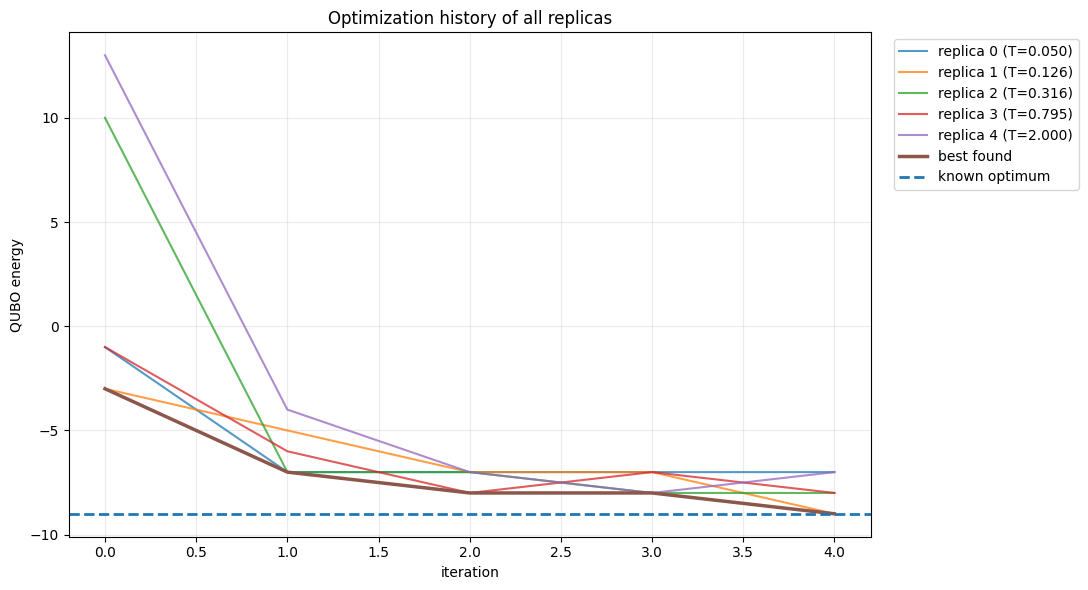

In [12]:
history_replicas_array = np.asarray(history_replicas)

plt.figure(figsize=(11, 6))

# Optimization trajectory of every temperature slot.
for r in range(num_replicas):
    plt.plot(
        history_replicas_array[:, r],
        label=f"replica {r} (T={temperatures[r]:.3f})",
        alpha=0.75,
    )

# Best solution found anywhere up to each iteration.
plt.plot(
    history_best,
    linewidth=2.5,
    label="best found",
)

# Known optimum for the 5 x 5 grid.
plt.axhline(
    exact_energy,
    linestyle="--",
    linewidth=2,
    label="known optimum",
)

plt.xlabel("iteration")
plt.ylabel("QUBO energy")
plt.title("Optimization history of all replicas")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

最後に、求まった解がどのようなグラフかを見てみましょう。

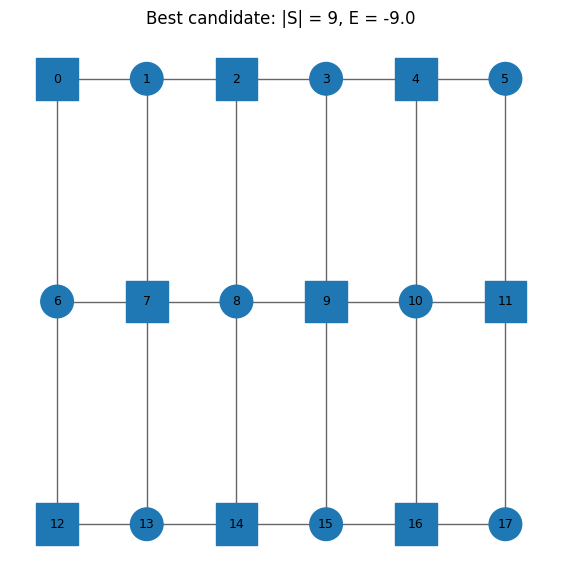

In [13]:
selected_mask = [bool(best_state[i]) for i in range(n)]
node_sizes = [900 if selected_mask[i] else 550 for i in range(n)]

plt.figure(figsize=(7, 7))
nx.draw_networkx_edges(graph, pos=positions, alpha=0.6)
nx.draw_networkx_nodes(
    graph,
    pos=positions,
    nodelist=[i for i in range(n) if not selected_mask[i]],
    node_size=[node_sizes[i] for i in range(n) if not selected_mask[i]],
)
nx.draw_networkx_nodes(
    graph,
    pos=positions,
    nodelist=[i for i in range(n) if selected_mask[i]],
    node_size=[node_sizes[i] for i in range(n) if selected_mask[i]],
    node_shape="s",
)
nx.draw_networkx_labels(graph, pos=positions, font_size=9)
plt.title(f"Best candidate: |S| = {len(selected_vertices)}, E = {best_energy:.1f}")
plt.axis("off")
plt.show()

予想通り、チェッカーボード状に頂点が選択されていることがわかります。

## まとめ

* 従来の QeMCMC とウォームスタート QAOA・レプリカ交換法を組合せた [Marshall et al. (2026)](https://arxiv.org/abs/2602.06171) をご紹介しました。
* 量子回路を用いて解を直接生成するのではなく、浅い量子回路を解の提案分布生成器として用いる手法です。
* 各反復後に得られた解を、次の反復でのウォームスタート初期状態とすることで、最適解探索を改善することができます。
* Qamomile には `ising_cost` 関数があり、これにより $e^{-i H_\mathrm{Ising} t}$ を容易に生成することができます。